# Valores y Vectores Propios en $\mathbb{R}^2$

**Proyecto 0.1 — Álgebra Lineal Visual con NumPy**  
*Portafolio: De Matemático a Data Scientist*

---

## Objetivo

Visualizar los valores y vectores propios como las **direcciones invariantes** de una
transformación lineal. Entender geométricamente por qué son fundamentales para
diagonalización, PCA, y prácticamente todo el ML que viene después.

> *"Un vector propio es una dirección que la transformación respeta, es decir, solo la escala, nunca la desvía."*

---
## Fundamento Matemático

### Definición

Sea $A \in \mathbb{R}^{n \times n}$. Un escalar $\lambda \in \mathbb{R}$ (o $\mathbb{C}$) es un **valor propio** de $A$
si existe un vector no nulo $\mathbf{v} \neq \mathbf{0}$ tal que:

$$A\mathbf{v} = \lambda \mathbf{v}$$

El vector $\mathbf{v}$ se llama **vector propio** asociado a $\lambda$.

### Interpretación geométrica

- La transformación $A$ actúa sobre $\mathbf{v}$ únicamente como un **escalado** por factor $\lambda$.
- Si $\lambda > 0$: el vector mantiene su dirección y sentido.
- Si $\lambda < 0$: el vector invierte su sentido.
- Si $\lambda = 0$: el vector es enviado al origen, es decir, pertenece al **núcleo**/**kernel** de $A$.
- Si $|\lambda| > 1$: el vector se estira.
- Si $|\lambda| < 1$: el vector se contrae.

### Polinomio característico

Los valores propios son las raíces del **polinomio característico**:

$$p(\lambda) = \det(A - \lambda I) = 0$$

Para $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$ en $\mathbb{R}^{2 \times 2}$:

$$p(\lambda) = \lambda^2 - (a+d)\lambda + (ad - bc) = \lambda^2 - \text{tr}(A)\lambda + \det(A)$$

donde $\text{tr}(A) = a + d$ es la **traza** de $A$.

### Propiedades fundamentales

| Propiedad | Fórmula |
|---|---|
| Suma de valores propios | $\lambda_1 + \lambda_2 + \cdots + \lambda_n = \text{tr}(A)$ |
| Producto de valores propios | $\lambda_1 \cdot \lambda_2 \cdots \lambda_n = \det(A)$ |
| Valores propios de $A^k$ | Son $\lambda_i^k$ |
| Valores propios de $A^{-1}$ | Son $1/\lambda_i$ (si $A$ es invertible) |
| Valores propios de $A + cI$ | Son $\lambda_i + c$ |

---
## Configuración inicial

In [1]:
%matplotlib inline

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.visualization import dibujar_vector, configurar_ejes, slugify

plt.rcParams.update({
    'figure.figsize': (8, 8),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
    'font.size': 12
})

print("Configuración cargada ✓")

Configuración cargada ✓


---
## Funciones auxiliares

In [2]:
print("Funciones auxiliares cargadas ✓")

Funciones auxiliares cargadas ✓


---
## 1. Cálculo manual vs NumPy

### Ejemplo: cálculo a mano

Sea $A = \begin{pmatrix} 3 & 1 \\ 0 & 2 \end{pmatrix}$.

**Polinomio característico:**

$$\det(A - \lambda I) = \det \begin{pmatrix} 3 - \lambda & 1 \\ 0 & 2 - \lambda \end{pmatrix} = (3-\lambda)(2-\lambda) - 0 = \lambda^2 - 5\lambda + 6$$

**Raíces:** $\lambda^2 - 5\lambda + 6 = (\lambda - 3)(\lambda - 2) = 0 \implies \lambda_1 = 3,\; \lambda_2 = 2$

**Vector propio para $\lambda_1 = 3$:**

$$(A - 3I)\mathbf{v} = \mathbf{0} \implies \begin{pmatrix} 0 & 1 \\ 0 & -1 \end{pmatrix}\mathbf{v} = \mathbf{0} \implies v_2 = 0 \implies \mathbf{v}_1 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

**Vector propio para $\lambda_2 = 2$:**

$$(A - 2I)\mathbf{v} = \mathbf{0} \implies \begin{pmatrix} 1 & 1 \\ 0 & 0 \end{pmatrix}\mathbf{v} = \mathbf{0} \implies v_1 = -v_2 \implies \mathbf{v}_2 = \begin{pmatrix} -1 \\ 1 \end{pmatrix}$$

### Verificación con NumPy

In [3]:
A = np.array([
    [3, 1],
    [0, 2]
])

# np.linalg.eig devuelve (valores_propios, matriz_de_vectores_propios)
# Las COLUMNAS de la matriz son los vectores propios
valores, vectores = np.linalg.eig(A)

print("=== Resultado de np.linalg.eig ===")
print(f"\nValores propios: λ₁ = {valores[0]:.6f}, λ₂ = {valores[1]:.6f}")
print(f"\nVector propio v₁ (columna 0): {vectores[:, 0]}")
print(f"Vector propio v₂ (columna 1): {vectores[:, 1]}")

# Verificación de la propiedad: Av = λv
print("\n=== Verificación: Av = λv ===")
for i in range(2):
    v = vectores[:, i]
    lam = valores[i]
    Av = A @ v
    lam_v = lam * v
    print(f"\nλ_{i+1} = {lam:.6f}")
    print(f"  Av     = {Av}")
    print(f"  λv     = {lam_v}")
    print(f"  ¿Av = λv? Error = {np.linalg.norm(Av - lam_v):.2e}")

=== Resultado de np.linalg.eig ===

Valores propios: λ₁ = 3.000000, λ₂ = 2.000000

Vector propio v₁ (columna 0): [1. 0.]
Vector propio v₂ (columna 1): [-0.70710678  0.70710678]

=== Verificación: Av = λv ===

λ_1 = 3.000000
  Av     = [3. 0.]
  λv     = [3. 0.]
  ¿Av = λv? Error = 0.00e+00

λ_2 = 2.000000
  Av     = [-1.41421356  1.41421356]
  λv     = [-1.41421356  1.41421356]
  ¿Av = λv? Error = 0.00e+00


In [4]:
# Verificación de las propiedades traza y determinante
traza = np.trace(A)
det = np.linalg.det(A)

print("=== Propiedades traza-determinante ===")
print(f"\ntr(A) = {traza:.6f}")
print(f"λ₁ + λ₂ = {valores[0] + valores[1]:.6f}")
print(f"¿Iguales? {np.isclose(traza, valores.sum())}")

print(f"\ndet(A) = {det:.6f}")
print(f"λ₁ · λ₂ = {valores[0] * valores[1]:.6f}")
print(f"¿Iguales? {np.isclose(det, valores.prod())}")

=== Propiedades traza-determinante ===

tr(A) = 5.000000
λ₁ + λ₂ = 5.000000
¿Iguales? True

det(A) = 6.000000
λ₁ · λ₂ = 6.000000
¿Iguales? True


> **Nota sobre `np.linalg.eig`:** NumPy devuelve vectores propios **normalizados** (con norma 1).
> El vector propio que calculamos a mano $(-1, 1)$ tiene norma $\sqrt{2}$.
> NumPy lo normaliza a $(-1/\sqrt{2},\; 1/\sqrt{2})$.
> Son el mismo vector propio, solo difieren por un escalar.
> Recordemos: si $\mathbf{v}$ es vector propio, $\alpha\mathbf{v}$ también lo es para todo $\alpha \neq 0$.

---
## 2. Visualización geométrica: direcciones invariantes

Los vectores propios son las direcciones que la transformación **no desvía**, solo escala.
Vamos a visualizar esto aplicando $A$ a muchos vectores y observando cuáles mantienen su dirección.

In [5]:
def visualizar_eigens(A, titulo):
    """
    Visualiza los vectores propios de A como direcciones invariantes.
    Muestra vectores antes y después de la transformación,
    destacando los que no cambian de dirección (los eigenvectors).

    Parámetros:
        A      : np.array (2,2) — la matriz
        titulo : string — título del gráfico
    """
    valores, vectores = np.linalg.eig(A)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Límites dinámicos: ax2 necesita acomodar vectores escalados por eigenvalores grandes
    lim1 = 3.5  # ax1: vectores originales de norma máx 2.5
    sigma_max = np.linalg.norm(A, ord=2)  # Norma espectral = mayor valor singular
    lim2 = max(sigma_max * 2.5 * 1.3, 3.5)  # ax2: transformados, con margen del 30%

    colores_eigen = ['#E91E63', '#4CAF50']
    angulos = np.linspace(0, 2*np.pi, 24, endpoint=False)

    # --- Panel izquierdo: vectores originales + eigenvectors ---
    for theta in angulos:
        v = np.array([np.cos(theta), np.sin(theta)])
        dibujar_vector(ax1, v * 2, color='#BBDEFB', lw=1)

    for i in range(len(valores)):
        if np.isreal(valores[i]):
            v = vectores[:, i].real
            dibujar_vector(ax1, v * 2.5, color=colores_eigen[i], lw=3)
            dibujar_vector(ax1, -v * 2.5, color=colores_eigen[i], lw=2)

    # Proxy artists: ax.annotate no registra artistas en la leyenda
    ax1.plot([], [], color='#BBDEFB', lw=1, label='Vectores del círculo unitario')
    for i in range(len(valores)):
        if np.isreal(valores[i]):
            lam = valores[i].real
            ax1.plot([], [], color=colores_eigen[i], lw=3,
                     label=f'$\\mathbf{{v}}_{i+1}$  ($\\lambda_{i+1}={lam:.2f}$)')

    configurar_ejes(ax1, 'Antes: vectores originales', lim=lim1)
    ax1.legend(loc='upper left', fontsize=10)

    # --- Panel derecho: vectores transformados + eigenvectors transformados ---
    for theta in angulos:
        v = np.array([np.cos(theta), np.sin(theta)])
        Av = A @ (v * 2)
        dibujar_vector(ax2, Av, color='#BBDEFB', lw=1)

    for i in range(len(valores)):
        if np.isreal(valores[i]):
            v = vectores[:, i].real
            lam = valores[i].real
            Av = A @ (v * 2.5)  # = λ · v · 2.5
            dibujar_vector(ax2, Av, color=colores_eigen[i], lw=3)
            dibujar_vector(ax2, -(A @ (v * 2.5)), color=colores_eigen[i], lw=2)

    # Proxy artists para la leyenda del panel derecho
    ax2.plot([], [], color='#BBDEFB', lw=1, label='Vectores transformados')
    for i in range(len(valores)):
        if np.isreal(valores[i]):
            lam = valores[i].real
            ax2.plot([], [], color=colores_eigen[i], lw=3,
                     label=f'$A\\mathbf{{v}}_{i+1} = {lam:.2f}\\,\\mathbf{{v}}_{i+1}$')

    configurar_ejes(ax2, 'Después: vectores transformados', lim=lim2)
    ax2.legend(loc='upper left', fontsize=10)

    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{slugify(titulo)}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Información numérica
    print(f"Valores propios: {valores}")
    print(f"tr(A) = {np.trace(A):.6f} = λ₁ + λ₂ = {valores.sum():.6f}")
    print(f"det(A) = {np.linalg.det(A):.6f} = λ₁ · λ₂ = {np.prod(valores):.6f}")

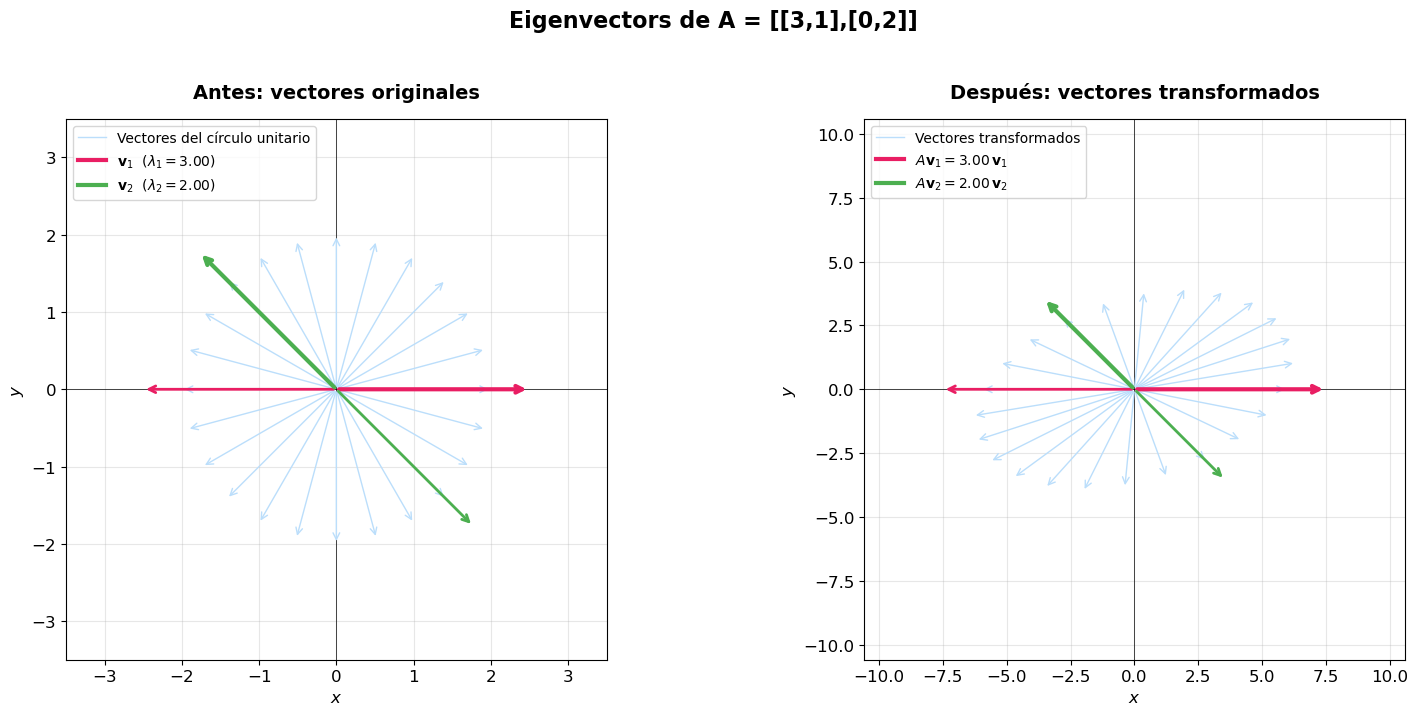

Valores propios: [3. 2.]
tr(A) = 5.000000 = λ₁ + λ₂ = 5.000000
det(A) = 6.000000 = λ₁ · λ₂ = 6.000000


In [6]:
# La matriz triangular superior del ejemplo
A1 = np.array([[3, 1],
               [0, 2]])

visualizar_eigens(A1, 'Eigenvectors de A = [[3,1],[0,2]]')

> **Observación:** Los vectores celestes cambian de dirección al aplicar $A$.
> Los vectores propios (rosa y verde) **solo cambian de longitud**, su dirección es invariante.
> Eso es exactamente lo que dice la ecuación $A\mathbf{v} = \lambda\mathbf{v}$.

---
## 3. Galería: eigenvectors de distintas transformaciones

Veamos cómo se comportan los vectores propios en las transformaciones del notebook anterior.

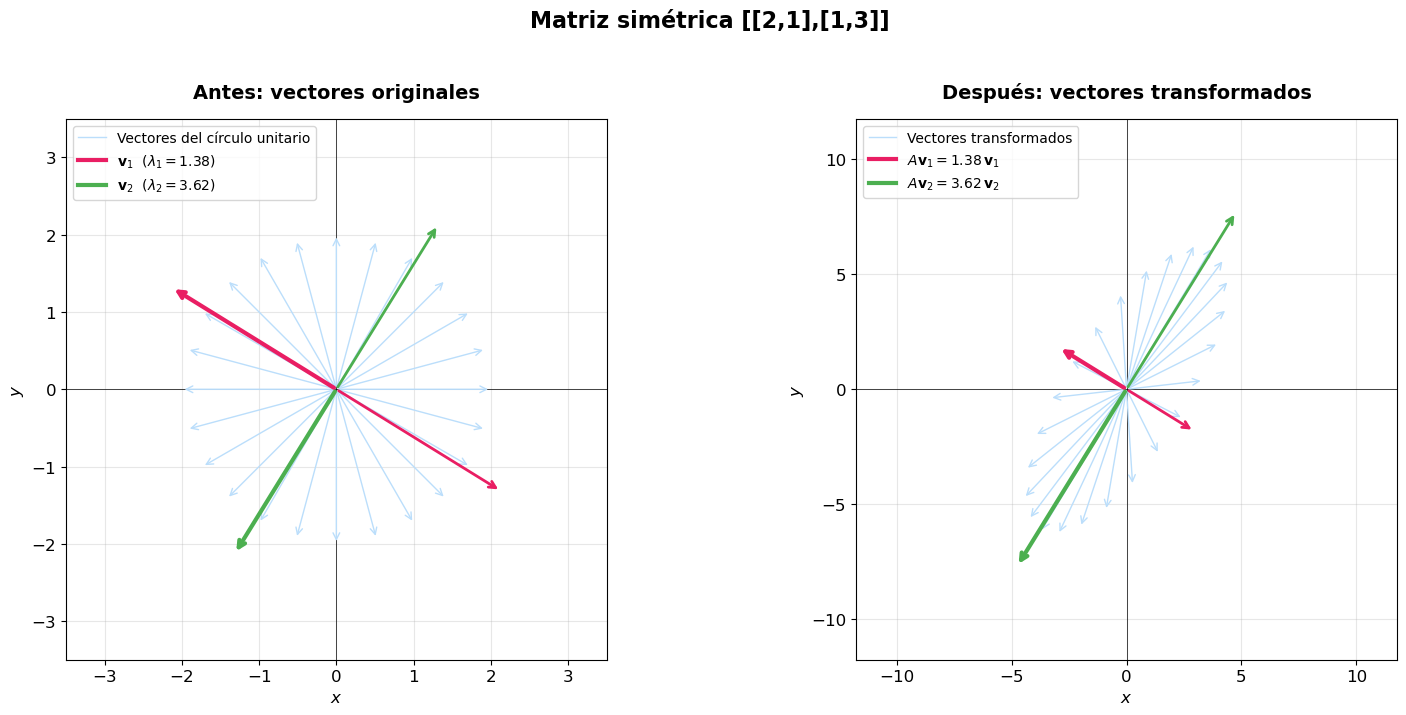

Valores propios: [1.38196601 3.61803399]
tr(A) = 5.000000 = λ₁ + λ₂ = 5.000000
det(A) = 5.000000 = λ₁ · λ₂ = 5.000000

Producto interno v₁ · v₂ = 0.00e+00
→ Ortogonales (producto interno ≈ 0), esto SIEMPRE pasa con matrices simétricas


In [7]:
# Matriz simétrica — eigenvalores siempre reales, eigenvectors ortogonales
A_sim = np.array([[2, 1],
                  [1, 3]])

visualizar_eigens(A_sim, 'Matriz simétrica [[2,1],[1,3]]')

# Verificar ortogonalidad de eigenvectors
_, vecs = np.linalg.eig(A_sim)
print(f"\nProducto interno v₁ · v₂ = {np.dot(vecs[:, 0], vecs[:, 1]):.2e}")
print("→ Ortogonales (producto interno ≈ 0), esto SIEMPRE pasa con matrices simétricas")

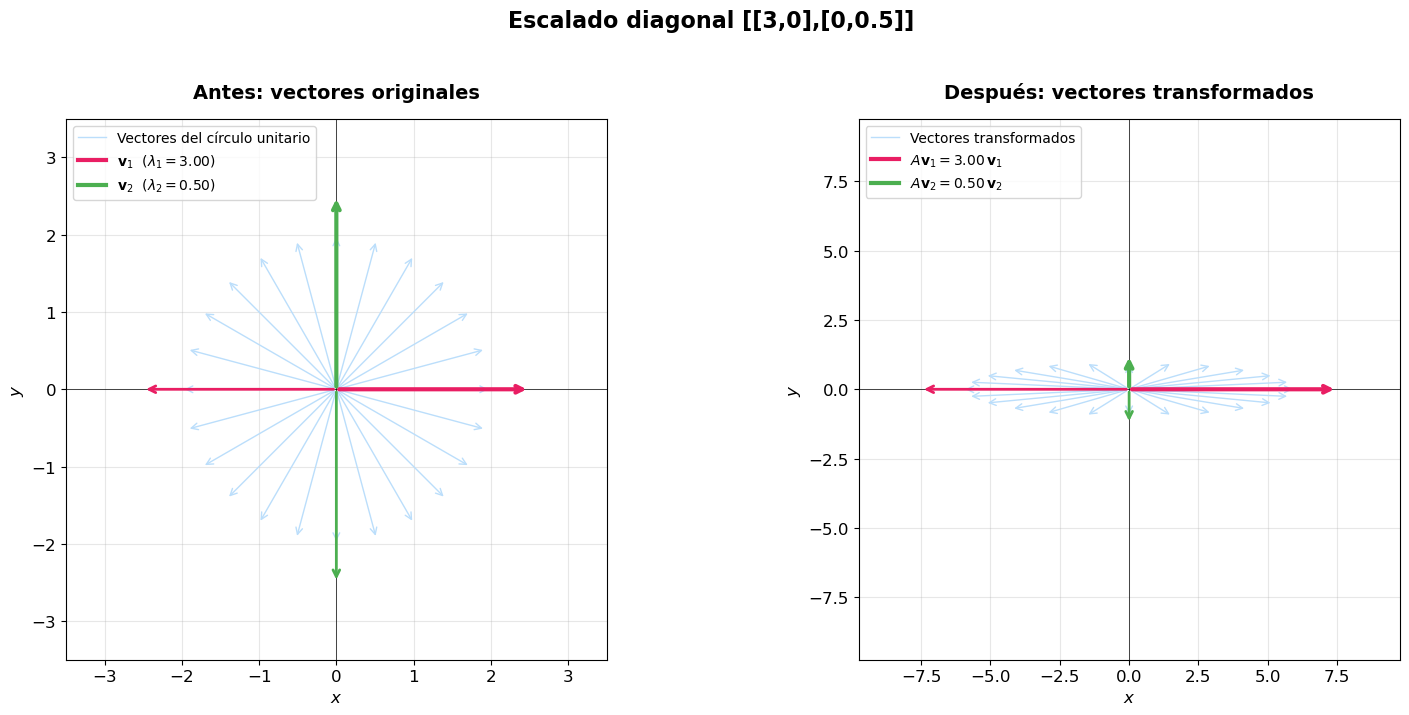

Valores propios: [3.  0.5]
tr(A) = 3.500000 = λ₁ + λ₂ = 3.500000
det(A) = 1.500000 = λ₁ · λ₂ = 1.500000

→ En matrices diagonales, los eigenvectors son siempre e₁ y e₂.
  Los eigenvalores son las entradas de la diagonal.


In [8]:
# Escalado (diagonal) — los eigenvectors son los ejes coordenados
D = np.array([[3, 0],
              [0, 0.5]])

visualizar_eigens(D, 'Escalado diagonal [[3,0],[0,0.5]]')

print("\n→ En matrices diagonales, los eigenvectors son siempre e₁ y e₂.")
print("  Los eigenvalores son las entradas de la diagonal.")

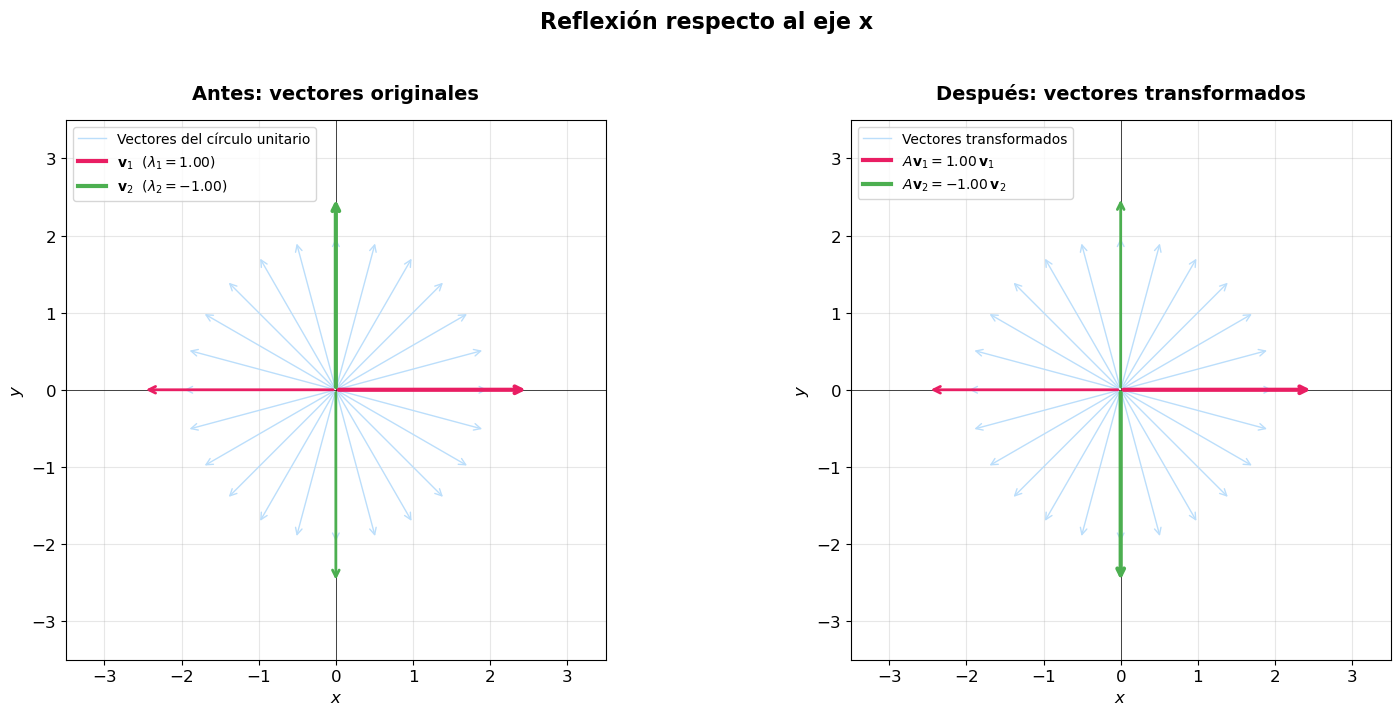

Valores propios: [ 1. -1.]
tr(A) = 0.000000 = λ₁ + λ₂ = 0.000000
det(A) = -1.000000 = λ₁ · λ₂ = -1.000000

→ λ = 1: el vector en el eje x no cambia (está SOBRE el espejo)
  λ = -1: el vector en el eje y se invierte (perpendicular al espejo)


In [9]:
# Reflexión respecto al eje x — eigenvalores: 1 y -1
S = np.array([[1,  0],
              [0, -1]])

visualizar_eigens(S, 'Reflexión respecto al eje x')

print("\n→ λ = 1: el vector en el eje x no cambia (está SOBRE el espejo)")
print("  λ = -1: el vector en el eje y se invierte (perpendicular al espejo)")

> **Definición — Multiplicidades de un eigenvalor** $\lambda_0$:
> - La **multiplicidad algebraica** es su multiplicidad como raíz del polinomio característico $p(\lambda) = \det(A - \lambda I)$.
> - La **multiplicidad geométrica** es $\dim(\ker(A - \lambda_0 I))$: el número de eigenvectors linealmente independientes asociados a $\lambda_0$.
>
> Siempre se cumple: mult. geométrica $\leq$ mult. algebraica.
> Cuando la igualdad se cumple para **todos** los eigenvalores, la matriz es diagonalizable.
> El siguiente ejemplo (cizallamiento) ilustra el caso degenerado en el que la desigualdad es estricta.

=== Cizallamiento ===
Eigenvalores: [1. 1.]
Eigenvectors: columnas de
[[ 1.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  1.48029737e-16]]

→ Ambos eigenvalores son 1, pero solo hay UNA dirección invariante (eje x).
  La matriz NO es diagonalizable — es un caso degenerado.
  Algebraicamente: la multiplicidad geométrica (1) < multiplicidad algebraica (2).


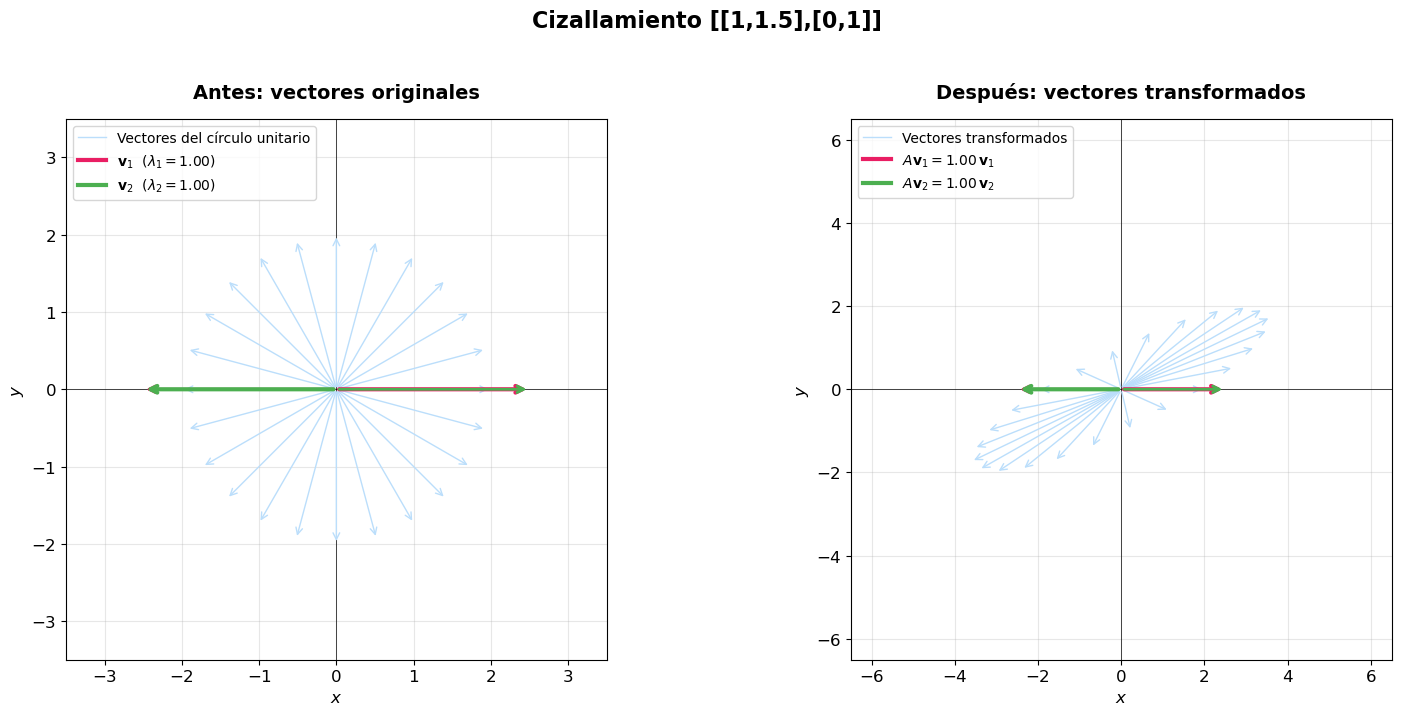

Valores propios: [1. 1.]
tr(A) = 2.000000 = λ₁ + λ₂ = 2.000000
det(A) = 1.000000 = λ₁ · λ₂ = 1.000000


In [10]:
# Cizallamiento — ambos eigenvalores iguales a 1
H = np.array([[1, 1.5],
              [0, 1]])

valores_H, vectores_H = np.linalg.eig(H)

print("=== Cizallamiento ===")
print(f"Eigenvalores: {valores_H}")
print(f"Eigenvectors: columnas de\n{vectores_H}")
print("\n→ Ambos eigenvalores son 1, pero solo hay UNA dirección invariante (eje x).")
print("  La matriz NO es diagonalizable — es un caso degenerado.")
print("  Algebraicamente: la multiplicidad geométrica (1) < multiplicidad algebraica (2).")

visualizar_eigens(H, 'Cizallamiento [[1,1.5],[0,1]]')

---
## 4. El caso de eigenvalores complejos: rotaciones

La matriz de rotación $R_\theta = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$
tiene polinomio característico:

$$p(\lambda) = \lambda^2 - 2\cos\theta\,\lambda + 1$$

Discriminante: $\Delta = 4\cos^2\theta - 4 = -4\sin^2\theta$

Para $\theta \neq 0, \pi$: $\Delta < 0 \implies$ **eigenvalores complejos conjugados:**

$$\lambda_{1,2} = \cos\theta \pm i\sin\theta = e^{\pm i\theta}$$

**Interpretación:** Una rotación pura (que no sea 0° o 180°) **no tiene direcciones invariantes reales**.
Esto tiene sentido geométricamente, una rotación mueve TODOS los vectores.

In [11]:
# Rotación de 45° — eigenvalores complejos
theta = np.radians(45)
R45 = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

valores_R, vectores_R = np.linalg.eig(R45)

print("=== Rotación 45° ===")
print(f"\nEigenvalores: {valores_R}")
print(f"\nλ₁ = {valores_R[0]:.4f} = cos(45°) + i·sin(45°) = e^(iπ/4)")
print(f"λ₂ = {valores_R[1]:.4f} = cos(45°) - i·sin(45°) = e^(-iπ/4)")
print(f"\n|λ₁| = {abs(valores_R[0]):.6f}  (módulo 1, preserva normas)")
print(f"|λ₂| = {abs(valores_R[1]):.6f}")
print(f"\n¿Son complejos? {np.iscomplex(valores_R).any()}")
print("\n→ No hay eigenvectors reales: la rotación mueve TODAS las direcciones.")

=== Rotación 45° ===

Eigenvalores: [0.70710678+0.70710678j 0.70710678-0.70710678j]

λ₁ = 0.7071+0.7071j = cos(45°) + i·sin(45°) = e^(iπ/4)
λ₂ = 0.7071-0.7071j = cos(45°) - i·sin(45°) = e^(-iπ/4)

|λ₁| = 1.000000  (módulo 1, preserva normas)
|λ₂| = 1.000000

¿Son complejos? True

→ No hay eigenvectors reales: la rotación mueve TODAS las direcciones.


---
## 5. Diagonalización

### Teorema

$A \in \mathbb{R}^{n \times n}$ es **diagonalizable** si y solo si la multiplicidad geométrica de cada eigenvalor es igual a su multiplicidad algebraica. En ese caso, existen $n$ eigenvectors linealmente independientes $\mathbf{v}_1, \ldots, \mathbf{v}_n$ y la factorización:

$$A = P D P^{-1}$$

donde:
- $P = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_n]$ es la matriz cuyas **columnas son los eigenvectors**
- $D = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_n)$ es la matriz diagonal con los **eigenvalores**

> **Condición práctica:** Si $A$ tiene $n$ eigenvalores distintos, es automáticamente diagonalizable (eigenvectors de eigenvalores distintos son linealmente independientes). Si hay eigenvalores repetidos, la igualdad mult. geométrica = mult. algebraica debe verificarse explícitamente — el cizallamiento es el ejemplo canónico donde falla.

### Interpretación geométrica

La factorización $A = PDP^{-1}$ descompone la transformación en tres pasos:

1. $P^{-1}$: cambio a la **base de eigenvectors** (rotar al sistema de coordenadas propio)
2. $D$: **escalado puro** a lo largo de cada dirección propia (ahora trivial — cada coordenada se multiplica por su eigenvalor)
3. $P$: **regresar** a la base original

### ¿Por qué importa en Data Science?

**PCA** (Principal Component Analysis) es exactamente esto: encontrar los eigenvectors
de la matriz de covarianza, cambiar de base y quedarse con las direcciones de mayor varianza.

In [12]:
# Diagonalización de la matriz simétrica
A_sim = np.array([[2, 1],
                  [1, 3]])

# np.linalg.eigh: especializado para matrices simétricas/hermitianas
# Garantiza eigenvalores reales y es numéricamente más estable que eig
# (no forma productos internos innecesarios que amplifiquen errores de redondeo)
valores, P = np.linalg.eigh(A_sim)
D = np.diag(valores)
P_inv = np.linalg.inv(P)

print("=== Diagonalización: A = P D P⁻¹ ===")
print(f"\nA =\n{A_sim}")
print(f"\nP (eigenvectors como columnas) =\n{P}")
print(f"\nD (eigenvalores en la diagonal) =\n{D}")
print(f"\nP⁻¹ =\n{P_inv}")

# Verificación: A = P D P⁻¹
A_reconstruida = P @ D @ P_inv
print(f"\nP D P⁻¹ =\n{A_reconstruida}")
print(f"\n¿A = P D P⁻¹? Error máximo = {np.max(np.abs(A_sim - A_reconstruida)):.2e}")

=== Diagonalización: A = P D P⁻¹ ===



A =
[[2 1]
 [1 3]]

P (eigenvectors como columnas) =
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]

D (eigenvalores en la diagonal) =
[[1.38196601 0.        ]
 [0.         3.61803399]]

P⁻¹ =
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]

P D P⁻¹ =
[[2. 1.]
 [1. 3.]]

¿A = P D P⁻¹? Error máximo = 4.44e-16


In [13]:
# Para matrices simétricas: P es ortogonal → P⁻¹ = Pᵀ
print("=== Propiedad especial de matrices simétricas ===")
print(f"\nP⁻¹ =\n{P_inv}")
print(f"\nPᵀ  =\n{P.T}")
print(f"\n¿P⁻¹ = Pᵀ? Error = {np.max(np.abs(P_inv - P.T)):.2e}")
print("\n→ En matrices simétricas, A = P D Pᵀ (descomposición espectral).")
print("  No necesitas calcular la inversa — basta con transponer.")
print("  Esto es computacionalmente importante: transponer es O(1), invertir es O(n³).")

=== Propiedad especial de matrices simétricas ===

P⁻¹ =
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]

Pᵀ  =
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]

¿P⁻¹ = Pᵀ? Error = 2.22e-16

→ En matrices simétricas, A = P D Pᵀ (descomposición espectral).
  No necesitas calcular la inversa — basta con transponer.
  Esto es computacionalmente importante: transponer es O(1), invertir es O(n³).


---
## 6. Potencias de matrices: $A^k = P D^k P^{-1}$

#### Teorema

Si $A = PDP^{-1}$, entonces:

$$A^k = P D^k P^{-1}$$

donde $D^k = \text{diag}(\lambda_1^k, \lambda_2^k, \ldots, \lambda_n^k)$.

Esto reduce elevar una matriz a una potencia a simplemente elevar escalares a una potencia.
Es la razón por la cual la diagonalización es tan útil computacionalmente.

In [14]:
# Calcular A^10 de dos formas y comparar
k = 10

# Forma 1: multiplicación directa (costosa para k grande)
A_k_directa = np.linalg.matrix_power(A_sim, k)

# Forma 2: via diagonalización (eficiente)
D_k = np.diag(valores ** k)  # Solo elevar escalares a la k
A_k_diag = P @ D_k @ P_inv

print(f"=== A^{k} ===")
print(f"\nMétodo directo:")
print(A_k_directa)
print(f"\nVía diagonalización:")
print(A_k_diag)
print(f"\nError máximo: {np.max(np.abs(A_k_directa - A_k_diag)):.2e}")

print(f"\nλ₁^{k} = {valores[0]:.4f}^{k} = {valores[0]**k:.4f}")
print(f"λ₂^{k} = {valores[1]:.4f}^{k} = {valores[1]**k:.4f}")

=== A^10 ===

Método directo:
[[106250 171875]
 [171875 278125]]

Vía diagonalización:
[[106250. 171875.]
 [171875. 278125.]]

Error máximo: 5.82e-11

λ₁^10 = 1.3820^10 = 25.4082
λ₂^10 = 3.6180^10 = 384349.5918


---
## 7. Visualización: efecto de aplicar $A$ repetidamente

¿Qué pasa si aplicamos $A$ una y otra vez a un vector? La respuesta depende
de los eigenvalores:
- Si $|\lambda| > 1$: el componente en esa dirección **crece** exponencialmente
- Si $|\lambda| < 1$: el componente en esa dirección **decae** a cero
- Si $|\lambda| = 1$: el componente en esa dirección **se mantiene**

In [15]:
# Matriz con un eigenvalor > 1 y otro < 1
A_mixta = np.array([[0.8, 0.3],
                    [0.2, 1.3]])

vals_m, vecs_m = np.linalg.eig(A_mixta)
print(f"Eigenvalores: λ₁ = {vals_m[0]:.4f}, λ₂ = {vals_m[1]:.4f}")
print(f"|λ₁| = {abs(vals_m[0]):.4f} {'> 1 → crece' if abs(vals_m[0]) > 1 else '< 1 → decae'}")
print(f"|λ₂| = {abs(vals_m[1]):.4f} {'> 1 → crece' if abs(vals_m[1]) > 1 else '< 1 → decae'}")

Eigenvalores: λ₁ = 0.7000, λ₂ = 1.4000
|λ₁| = 0.7000 < 1 → decae
|λ₂| = 1.4000 > 1 → crece


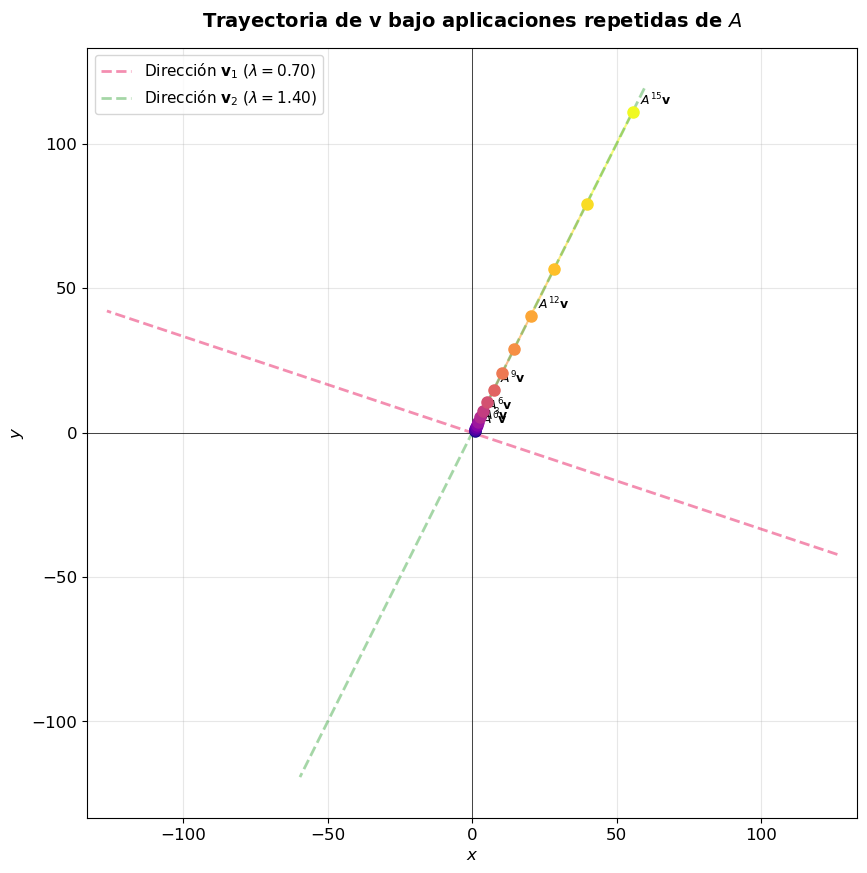


→ La trayectoria se alinea con el eigenvector DOMINANTE (|λ| más grande).
  Este principio es la base del Power Method para calcular eigenvalores.
  También explica por qué PCA encuentra las direcciones de mayor varianza.


In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

# Trayectoria de un vector bajo aplicaciones repetidas de A
v0 = np.array([1.0, 0.5])
trayectoria = [v0.copy()]
n_pasos = 15

v_actual = v0.copy()
for _ in range(n_pasos):
    v_actual = A_mixta @ v_actual
    trayectoria.append(v_actual.copy())

trayectoria = np.array(trayectoria)

# Dibujar trayectoria
colores = plt.cm.plasma(np.linspace(0, 1, len(trayectoria)))
for i in range(len(trayectoria)):
    ax.plot(trayectoria[i, 0], trayectoria[i, 1], 'o',
            color=colores[i], markersize=8, zorder=5)
    if i > 0:
        ax.plot([trayectoria[i-1, 0], trayectoria[i, 0]],
                [trayectoria[i-1, 1], trayectoria[i, 1]],
                '-', color=colores[i], alpha=0.6, lw=1.5)
    if i % 3 == 0:  # Etiquetar cada 3 pasos
        ax.annotate(f'$A^{{{i}}}\mathbf{{v}}$',
                    xy=(trayectoria[i, 0], trayectoria[i, 1]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

# Dibujar las direcciones propias
vals, vecs = np.linalg.eig(A_mixta)
lim = max(abs(trayectoria).max() * 1.2, 5)
for i in range(2):
    if np.isreal(vals[i]):
        v_dir = vecs[:, i].real
        t_linea = np.linspace(-lim, lim, 100)
        ax.plot(v_dir[0] * t_linea, v_dir[1] * t_linea,
                '--', color=['#E91E63', '#4CAF50'][i], alpha=0.5, lw=2,
                label=f'Dirección $\mathbf{{v}}_{i+1}$ ($\lambda={vals[i].real:.2f}$)')

configurar_ejes(ax, f'Trayectoria de $\mathbf{{v}}$ bajo aplicaciones repetidas de $A$', lim=lim)
ax.legend(loc='upper left', fontsize=11)

plt.savefig('../reports/figures/trayectoria_potencias_A.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n→ La trayectoria se alinea con el eigenvector DOMINANTE (|λ| más grande).")
print("  Este principio es la base del Power Method para calcular eigenvalores.")
print("  También explica por qué PCA encuentra las direcciones de mayor varianza.")

In [17]:
# Descomposición espectral: A = λ₁ v₁v₁ᵀ + λ₂ v₂v₂ᵀ
A_sim = np.array([[2, 1],
                  [1, 3]])

# eigh garantiza eigenvalores reales y eigenvectors ortogonales para matrices simétricas
valores, vectores = np.linalg.eigh(A_sim)

# Cada término de la suma
v1 = vectores[:, 0].reshape(-1, 1)  # Columna
v2 = vectores[:, 1].reshape(-1, 1)

termino_1 = valores[0] * (v1 @ v1.T)
termino_2 = valores[1] * (v2 @ v2.T)

print("=== Descomposición espectral ===")
print(f"\nλ₁ = {valores[0]:.4f}")
print(f"λ₁ · v₁v₁ᵀ =\n{termino_1}")
print(f"\nλ₂ = {valores[1]:.4f}")
print(f"λ₂ · v₂v₂ᵀ =\n{termino_2}")
print(f"\nSuma = λ₁v₁v₁ᵀ + λ₂v₂v₂ᵀ =\n{termino_1 + termino_2}")
print(f"\nA original =\n{A_sim}")
print(f"\n¿Son iguales? Error = {np.max(np.abs(A_sim - (termino_1 + termino_2))):.2e}")

=== Descomposición espectral ===

λ₁ = 1.3820
λ₁ · v₁v₁ᵀ =
[[ 1.         -0.61803399]
 [-0.61803399  0.38196601]]

λ₂ = 3.6180
λ₂ · v₂v₂ᵀ =
[[1.         1.61803399]
 [1.61803399 2.61803399]]

Suma = λ₁v₁v₁ᵀ + λ₂v₂v₂ᵀ =
[[2. 1.]
 [1. 3.]]

A original =
[[2 1]
 [1 3]]

¿Son iguales? Error = 6.66e-16


In [18]:
# Descomposición espectral: A = λ₁ v₁v₁ᵀ + λ₂ v₂v₂ᵀ
A_sim = np.array([[2, 1],
                  [1, 3]])

valores, vectores = np.linalg.eig(A_sim)

# Cada término de la suma
v1 = vectores[:, 0].reshape(-1, 1)  # Columna
v2 = vectores[:, 1].reshape(-1, 1)

termino_1 = valores[0] * (v1 @ v1.T)
termino_2 = valores[1] * (v2 @ v2.T)

print("=== Descomposición espectral ===")
print(f"\nλ₁ = {valores[0]:.4f}")
print(f"λ₁ · v₁v₁ᵀ =\n{termino_1}")
print(f"\nλ₂ = {valores[1]:.4f}")
print(f"λ₂ · v₂v₂ᵀ =\n{termino_2}")
print(f"\nSuma = λ₁v₁v₁ᵀ + λ₂v₂v₂ᵀ =\n{termino_1 + termino_2}")
print(f"\nA original =\n{A_sim}")
print(f"\n¿Son iguales? Error = {np.max(np.abs(A_sim - (termino_1 + termino_2))):.2e}")

=== Descomposición espectral ===

λ₁ = 1.3820
λ₁ · v₁v₁ᵀ =
[[ 1.         -0.61803399]
 [-0.61803399  0.38196601]]

λ₂ = 3.6180
λ₂ · v₂v₂ᵀ =
[[1.         1.61803399]
 [1.61803399 2.61803399]]

Suma = λ₁v₁v₁ᵀ + λ₂v₂v₂ᵀ =
[[2. 1.]
 [1. 3.]]

A original =
[[2 1]
 [1 3]]

¿Son iguales? Error = 6.66e-16


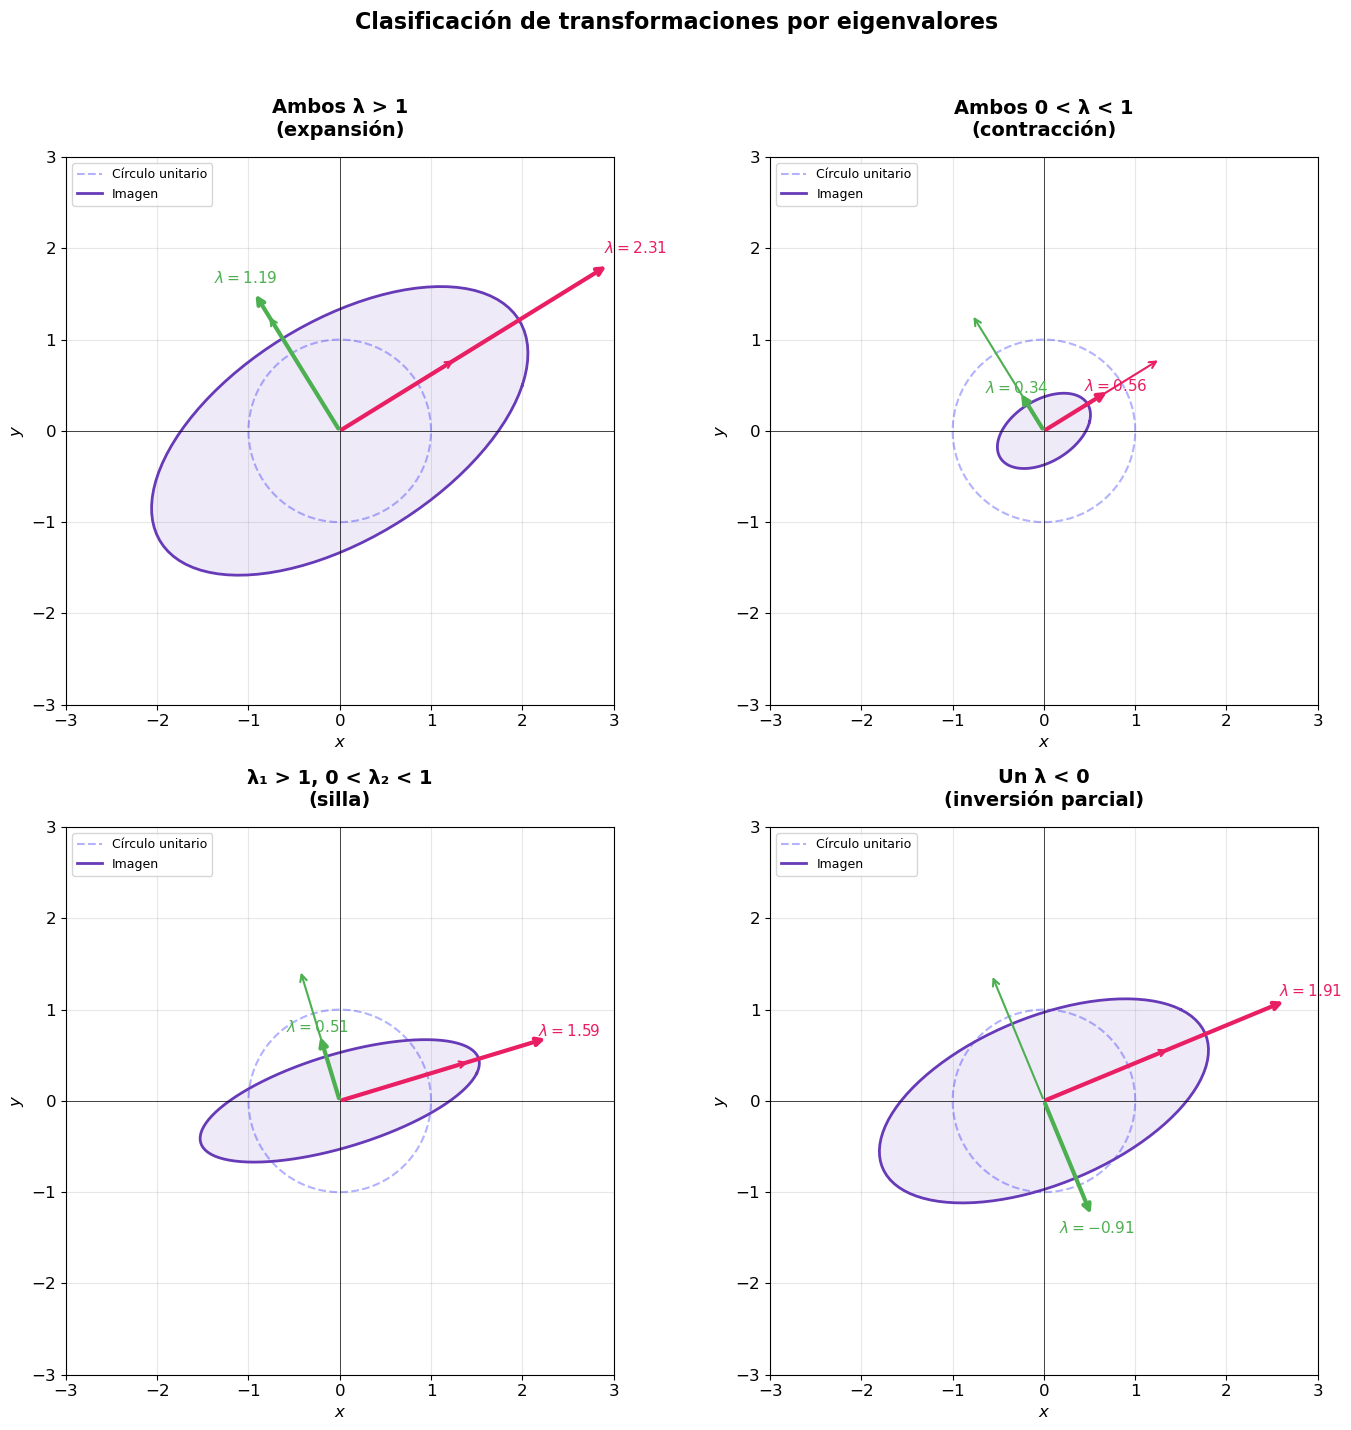

In [19]:
# Cuatro casos representativos
casos = {
    'Ambos λ > 1\n(expansión)': np.array([[2, 0.5], [0.5, 1.5]]),
    'Ambos 0 < λ < 1\n(contracción)': np.array([[0.5, 0.1], [0.1, 0.4]]),
    'λ₁ > 1, 0 < λ₂ < 1\n(silla)': np.array([[1.5, 0.3], [0.3, 0.6]]),
    'Un λ < 0\n(inversión parcial)': np.array([[1.5, 1], [1, -0.5]])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

# Círculo unitario para visualizar la deformación
theta_circ = np.linspace(0, 2*np.pi, 100)
circulo = np.array([np.cos(theta_circ), np.sin(theta_circ)])

for ax, (nombre, A) in zip(axes, casos.items()):
    vals, vecs = np.linalg.eig(A)
    
    # Círculo original
    ax.plot(circulo[0], circulo[1], 'b--', alpha=0.3, lw=1.5, label='Círculo unitario')
    
    # Elipse (imagen del círculo bajo A)
    elipse = A @ circulo
    ax.plot(elipse[0], elipse[1], color='#673AB7', lw=2, label='Imagen')
    ax.fill(elipse[0], elipse[1], color='#673AB7', alpha=0.1)
    
    # Eigenvectors escalados por eigenvalor
    for i in range(2):
        if np.isreal(vals[i]):
            v = vecs[:, i].real
            lam = vals[i].real
            color = '#E91E63' if i == 0 else '#4CAF50'
            # Dirección original (norma 1)
            dibujar_vector(ax, v * 1.5, color=color, lw=1.5)
            # Dirección escalada (norma λ)
            dibujar_vector(ax, v * lam * 1.5, color=color, lw=3,
                          label=f'$\lambda={lam:.2f}$')
    
    configurar_ejes(ax, nombre, lim=3)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Clasificación de transformaciones por eigenvalores',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/clasificacion_eigenvalores.png',
            dpi=150, bbox_inches='tight')
plt.show()

> **Observación clave:** La imagen del círculo unitario bajo $A$ es siempre una **elipse**
> (o un segmento si $\det(A) = 0$). Los ejes de la elipse son exactamente las direcciones
> de los eigenvectors, y las longitudes de los semiejes son los valores absolutos de los eigenvalores.
>
> Esta conexión entre elipses y eigenvalores es central en estadística: la **elipse de confianza**
> de una distribución normal multivariante está definida por los eigenvalores de la covarianza.

# Cuatro casos representativos
casos = {
    'Ambos λ > 1\n(expansión)': np.array([[2, 0.5], [0.5, 1.5]]),
    'Ambos 0 < λ < 1\n(contracción)': np.array([[0.5, 0.1], [0.1, 0.4]]),
    'λ₁ > 1, 0 < λ₂ < 1\n(silla)': np.array([[1.5, 0.3], [0.3, 0.6]]),
    'Un λ < 0\n(inversión parcial)': np.array([[1.5, 1], [1, -0.5]])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

# Círculo unitario para visualizar la deformación
theta_circ = np.linspace(0, 2*np.pi, 100)
circulo = np.array([np.cos(theta_circ), np.sin(theta_circ)])

colores_eigen = ['#E91E63', '#4CAF50']

for ax, (nombre, A) in zip(axes, casos.items()):
    vals, vecs = np.linalg.eig(A)

    # Límite dinámico: acomodar eigenvectors escalados por eigenvalor (factor 1.5) + 30%
    sigma_max = np.linalg.norm(A, ord=2)
    lim = max(sigma_max * 1.5 * 1.3, 2.5)

    # Círculo original
    ax.plot(circulo[0], circulo[1], 'b--', alpha=0.3, lw=1.5)

    # Elipse (imagen del círculo bajo A)
    elipse = A @ circulo
    ax.plot(elipse[0], elipse[1], color='#673AB7', lw=2)
    ax.fill(elipse[0], elipse[1], color='#673AB7', alpha=0.1)

    # Eigenvectors escalados (sin label — la leyenda usa proxy artists)
    for i in range(2):
        if np.isreal(vals[i]):
            v = vecs[:, i].real
            lam = vals[i].real
            color = colores_eigen[i]
            dibujar_vector(ax, v * 1.5, color=color, lw=1.5)
            dibujar_vector(ax, v * lam * 1.5, color=color, lw=3)

    # Proxy artists para la leyenda
    ax.plot([], [], 'b--', alpha=0.6, lw=1.5, label='Círculo unitario')
    ax.plot([], [], color='#673AB7', lw=2, label='Imagen bajo $A$')
    for i in range(2):
        if np.isreal(vals[i]):
            lam = vals[i].real
            ax.plot([], [], color=colores_eigen[i], lw=3,
                    label=f'$\\lambda={lam:.2f}$')

    configurar_ejes(ax, nombre, lim=lim)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Clasificación de transformaciones por eigenvalores',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/clasificacion_eigenvalores.png',
            dpi=150, bbox_inches='tight')
plt.show()